In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


ROOT = "../simulacoes/tfb_multi_lb_predlen_carteiras"
ARQ = f"{ROOT}/comparativo_metricas_long.csv"

THRESHOLD_PRECISION = 0.595
THRESHOLD_IC = 0.05

df_long = pd.read_csv(ARQ)

KEYS = ["tipo_serie", "modelo", "lookback", "pred_len", "janela_previsao"]

df_wide = (
    df_long
    .pivot_table(
        index=KEYS,
        columns="estatistica",
        values="valor",
        aggfunc="first",
    )
    .reset_index()
)

df_wide = df_wide.rename(columns={"tipo_serie": "tipo_dado"})

#df_export = df_wide[df_wide["mean_precision_positive"] >= THRESHOLD_PRECISION].copy()
df_export = df_wide[df_wide["mean_spearman_ic"] >= THRESHOLD_IC].copy()

df_export.shape

(364, 15)

In [2]:
pct_prices = (df_export["tipo_dado"] == "prices").mean() * 100
print(f"A. Percentual de 'prices' em tipo_dado: {pct_prices:.2f}%")
print("-" * 50)

print("B. Distribuição percentual de lookback:")
print((df_export["lookback"].value_counts(normalize=True) * 100).map("{:.2f}%".format))
print("-" * 50)

print("C. Distribuição percentual de pred_len:")
print((df_export["pred_len"].value_counts(normalize=True) * 100).map("{:.2f}%".format))
print("-" * 50)

print("D. Distribuição percentual de janela_previsao:")
print((df_export["janela_previsao"].value_counts(normalize=True) * 100).map("{:.2f}%".format))
print("-" * 50)

print("E. Distribuição percentual de modelo:")
print((df_export["modelo"].value_counts(normalize=True) * 100).map("{:.2f}%".format))

A. Percentual de 'prices' em tipo_dado: 46.98%
--------------------------------------------------
B. Distribuição percentual de lookback:
lookback
104    46.15%
246    36.26%
32     17.58%
Name: proportion, dtype: str
--------------------------------------------------
C. Distribuição percentual de pred_len:
pred_len
24    41.21%
15    26.37%
10    18.68%
5     10.71%
1      3.02%
Name: proportion, dtype: str
--------------------------------------------------
D. Distribuição percentual de janela_previsao:
janela_previsao
5     27.47%
10    22.53%
1     19.78%
15    15.11%
20     7.69%
24     7.42%
Name: proportion, dtype: str
--------------------------------------------------
E. Distribuição percentual de modelo:
modelo
DUET                         30.22%
TimesNet                     26.37%
Nonstationary_Transformer    23.90%
FEDformer                    19.51%
Name: proportion, dtype: str


In [3]:
tab_pred_k = (
    df_export
    .groupby(["pred_len", "janela_previsao"])
    .size()
    .rename("n")
    .reset_index()
)

tab_pred_k["pct_global"] = 100 * tab_pred_k["n"] / tab_pred_k["n"].sum()

tab_pred_k["pct_dentro_pred_len"] = (
    tab_pred_k
    .groupby("pred_len")["n"]
    .transform(lambda x: 100 * x / x.sum())
)

tab_pred_k


,pred_len,janela_previsao,n,pct_global,pct_dentro_pred_len
0,1,1,11,3.021978,100.000000
1,5,1,14,3.846154,35.897436
2,5,5,25,6.868132,64.102564
3,10,1,15,4.120879,22.058824
4,10,5,25,6.868132,36.764706
5,10,10,28,7.692308,41.176471
6,15,1,16,4.395604,16.666667
7,15,5,25,6.868132,26.041667
8,15,10,27,7.417582,28.125000
9,15,15,28,7.692308,29.166667


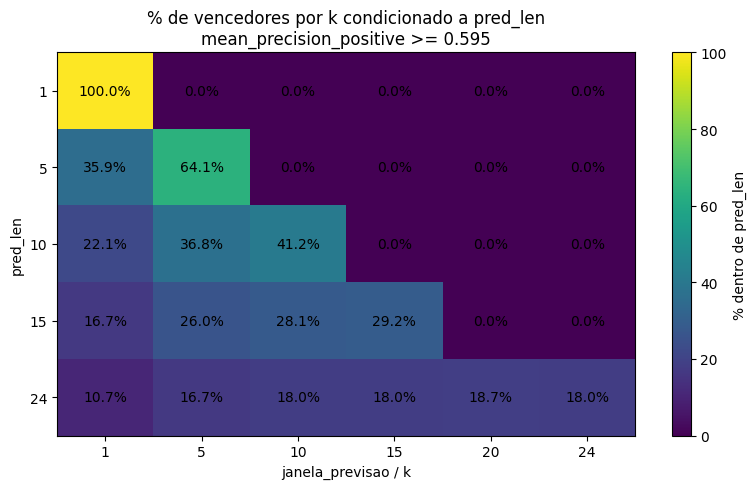

In [4]:

heat = tab_pred_k.pivot(
    index="pred_len",
    columns="janela_previsao",
    values="pct_dentro_pred_len",
).fillna(0)

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(heat.values, aspect="auto")

ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns)

ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)

ax.set_xlabel("janela_previsao / k")
ax.set_ylabel("pred_len")
ax.set_title(f"% de vencedores por k condicionado a pred_len\nmean_precision_positive >= {THRESHOLD_PRECISION}")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.1f}%", ha="center", va="center")

plt.colorbar(im, ax=ax, label="% dentro de pred_len")
plt.tight_layout()
plt.show()

In [5]:
resumo_pred_k = (
    df_wide
    .groupby(["pred_len", "janela_previsao"])
    .agg(
        n=("mean_precision_positive", "size"),
        precision_media=("mean_precision_positive", "mean"),
        precision_mediana=("mean_precision_positive", "median"),
        precision_max=("mean_precision_positive", "max"),
        sharpe_medio=("sharpe", "mean"),
        retorno_medio=("annual_return", "mean"),
    )
    .reset_index()
    .sort_values(["pred_len", "janela_previsao"])
)

resumo_pred_k

,pred_len,janela_previsao,n,precision_media,precision_mediana,precision_max,sharpe_medio,retorno_medio
0,1,1,36,0.510326,0.507578,0.542300,2.868087,0.747348
1,5,1,36,0.508159,0.502454,0.543902,2.739768,0.722281
2,5,5,36,0.557210,0.559942,0.623782,2.987631,0.751021
3,10,1,36,0.511065,0.510002,0.545034,2.950320,0.762247
4,10,5,36,0.561596,0.567109,0.632252,3.194096,0.789931
5,10,10,36,0.593048,0.599415,0.676413,2.797720,0.765094
6,15,1,36,0.510485,0.511091,0.546941,2.987442,0.772049
7,15,5,36,0.558304,0.563988,0.632823,3.122942,0.771314
8,15,10,36,0.596190,0.604167,0.683248,2.876550,0.792487
9,15,15,36,0.616768,0.643275,0.725146,2.837236,0.798369


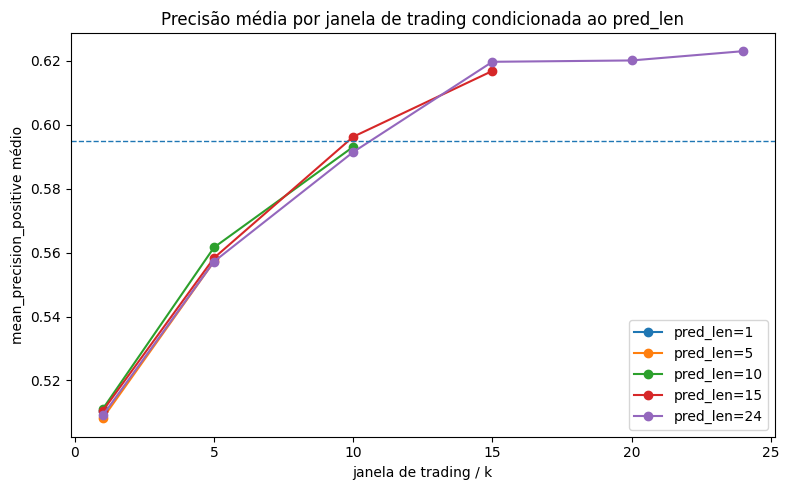

In [16]:
plt.figure(figsize=(8, 5))

for pred_len, base in resumo_pred_k.groupby("pred_len"):
    plt.plot(
        base["janela_previsao"],
        base["precision_media"],
        marker="o",
        label=f"pred_len={pred_len}",
    )

plt.axhline(THRESHOLD_PRECISION, linestyle="--", linewidth=1)

plt.xlabel("janela de trading / k")
plt.ylabel("mean_precision_positive médio")
plt.title("Precisão média por janela de trading condicionada ao pred_len")
plt.legend()
plt.tight_layout()
plt.show()

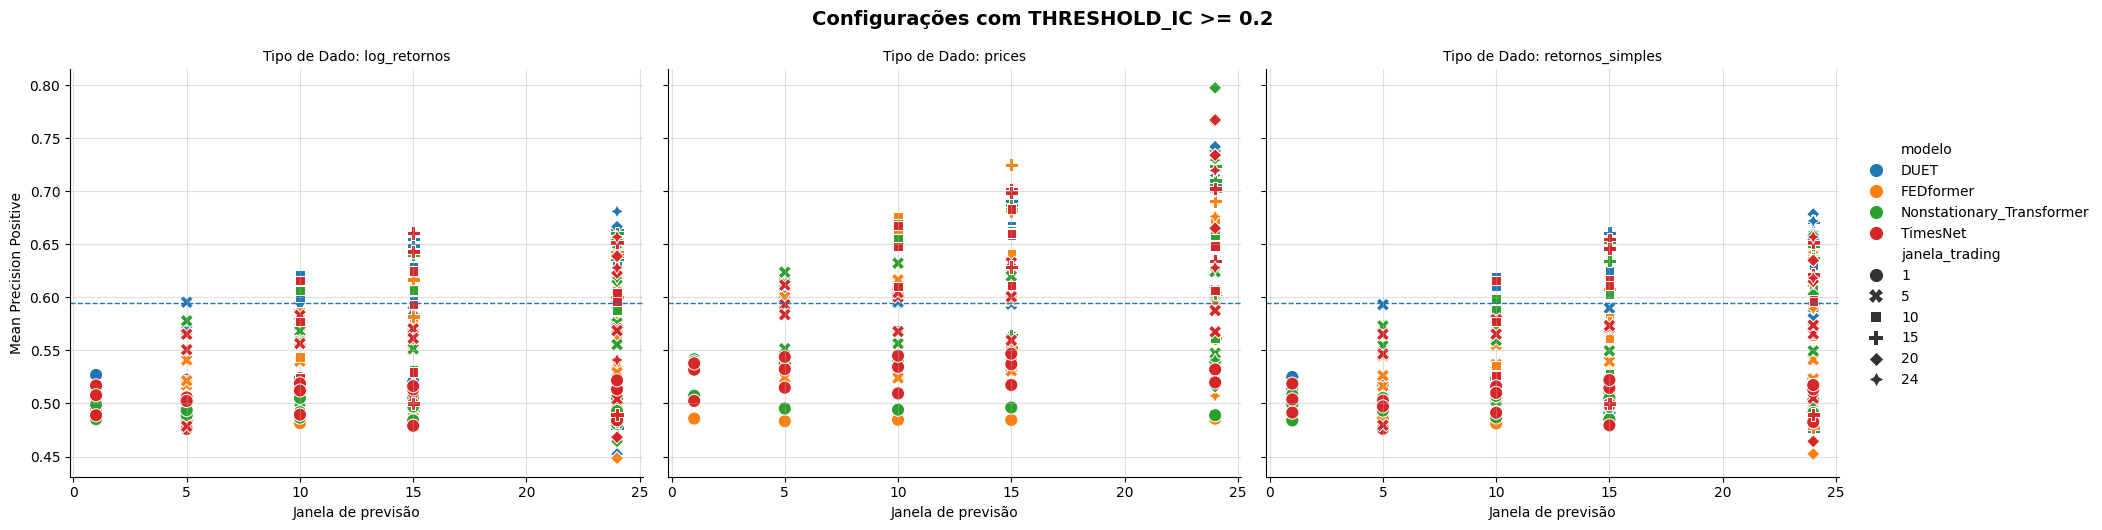

In [13]:
THRESHOLD_IC = 0.2
MIN_N_ASSETS = 1.0

df_export = df_wide[
    (df_wide["mean_spearman_ic"] >= THRESHOLD_IC) &
    (df_wide["mean_n_assets"] >= MIN_N_ASSETS)
].copy()


df_plot = df_export.copy()
#df_plot["janela_previsao"] = df_plot["janela_previsao"].astype(int)
df_plot = df_wide.rename(columns={"janela_previsao":"janela_trading"})


df_plot["lookback_label"] = "lookback_" + df_plot["lookback"].astype(int).astype(str)
df_plot["k_label"] = "k_" + df_plot["janela_trading"].astype(int).astype(str)

g = sns.relplot(
    data=df_plot,
    x="pred_len",
    y="mean_precision_positive",
    hue="modelo",
    style="janela_trading",
    col="tipo_dado",
    kind="scatter",
    height=5,
    aspect=1.25,
    s=90,
)

g.set_axis_labels("Janela de previsão", "Mean Precision Positive")
g.set_titles("Tipo de Dado: {col_name}")

for ax in g.axes.flat:
    ax.axhline(THRESHOLD_PRECISION, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.4)

g.fig.suptitle(
    f"Configurações com THRESHOLD_IC >= {THRESHOLD_IC}",
    y=1.05,
    fontsize=14,
    fontweight="bold",
)

plt.show()

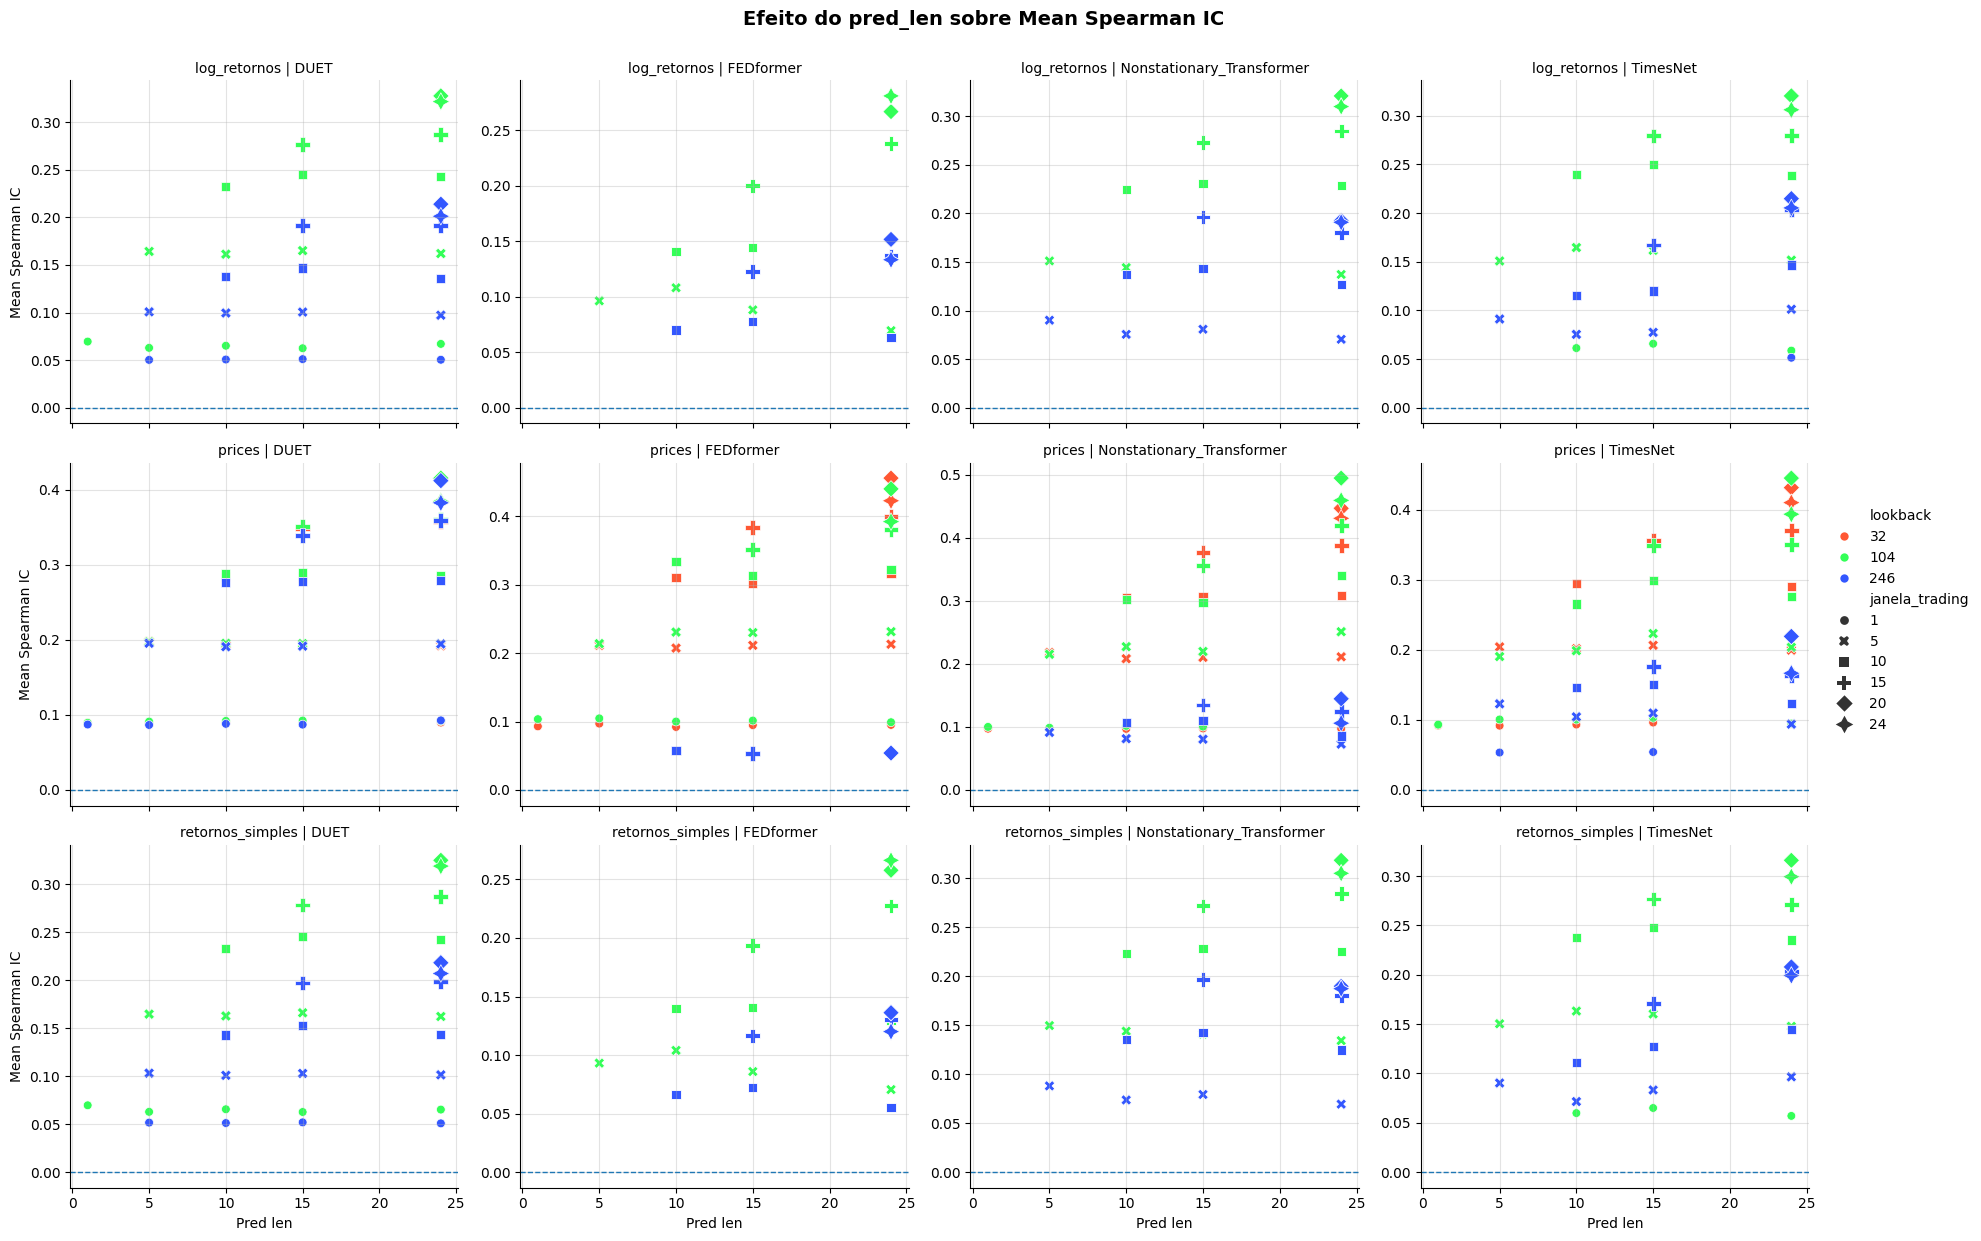

In [14]:

KEYS = ["tipo_serie", "modelo", "lookback", "pred_len", "janela_previsao"]

df_wide = (
    df_long
    .pivot_table(
        index=KEYS,
        columns="estatistica",
        values="valor",
        aggfunc="first",
    )
    .reset_index()
    .rename(columns={"tipo_serie": "tipo_dado"})
)

df_wide["lookback"] = df_wide["lookback"].astype(int)
df_wide["pred_len"] = df_wide["pred_len"].astype(int)
df_wide["janela_previsao"] = df_wide["janela_previsao"].astype(int)
df_wide = df_wide.rename(columns={"janela_previsao":"janela_trading"})

THRESHOLD_IC = 0.05
MIN_N_ASSETS = 5.0

df_plot = df_wide[
    (df_wide["mean_spearman_ic"] >= THRESHOLD_IC) &
    (df_wide["mean_n_assets"] >= MIN_N_ASSETS)
].copy()




g = sns.relplot(
    data=df_plot,
    x="pred_len",
    y="mean_spearman_ic",
    hue="lookback",
    style="janela_trading",
    size="janela_trading",
    col="modelo",
    row="tipo_dado",
    kind="scatter",
    height=4,
    aspect=1.15,
    sizes=(40, 160),
    facet_kws={"sharey": False},
    palette={32: "#FF5733", 104: "#33FF57", 246: "#3357FF"}  # <--- CORES PERSONALIZADAS AQUI
)

g.set_axis_labels("Pred len", "Mean Spearman IC")
g.set_titles("{row_name} | {col_name}")

for ax in g.axes.flat:
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.35)

g.fig.suptitle(
    "Efeito do pred_len sobre Mean Spearman IC",
    y=1.03,
    fontsize=14,
    fontweight="bold",
)

plt.show()

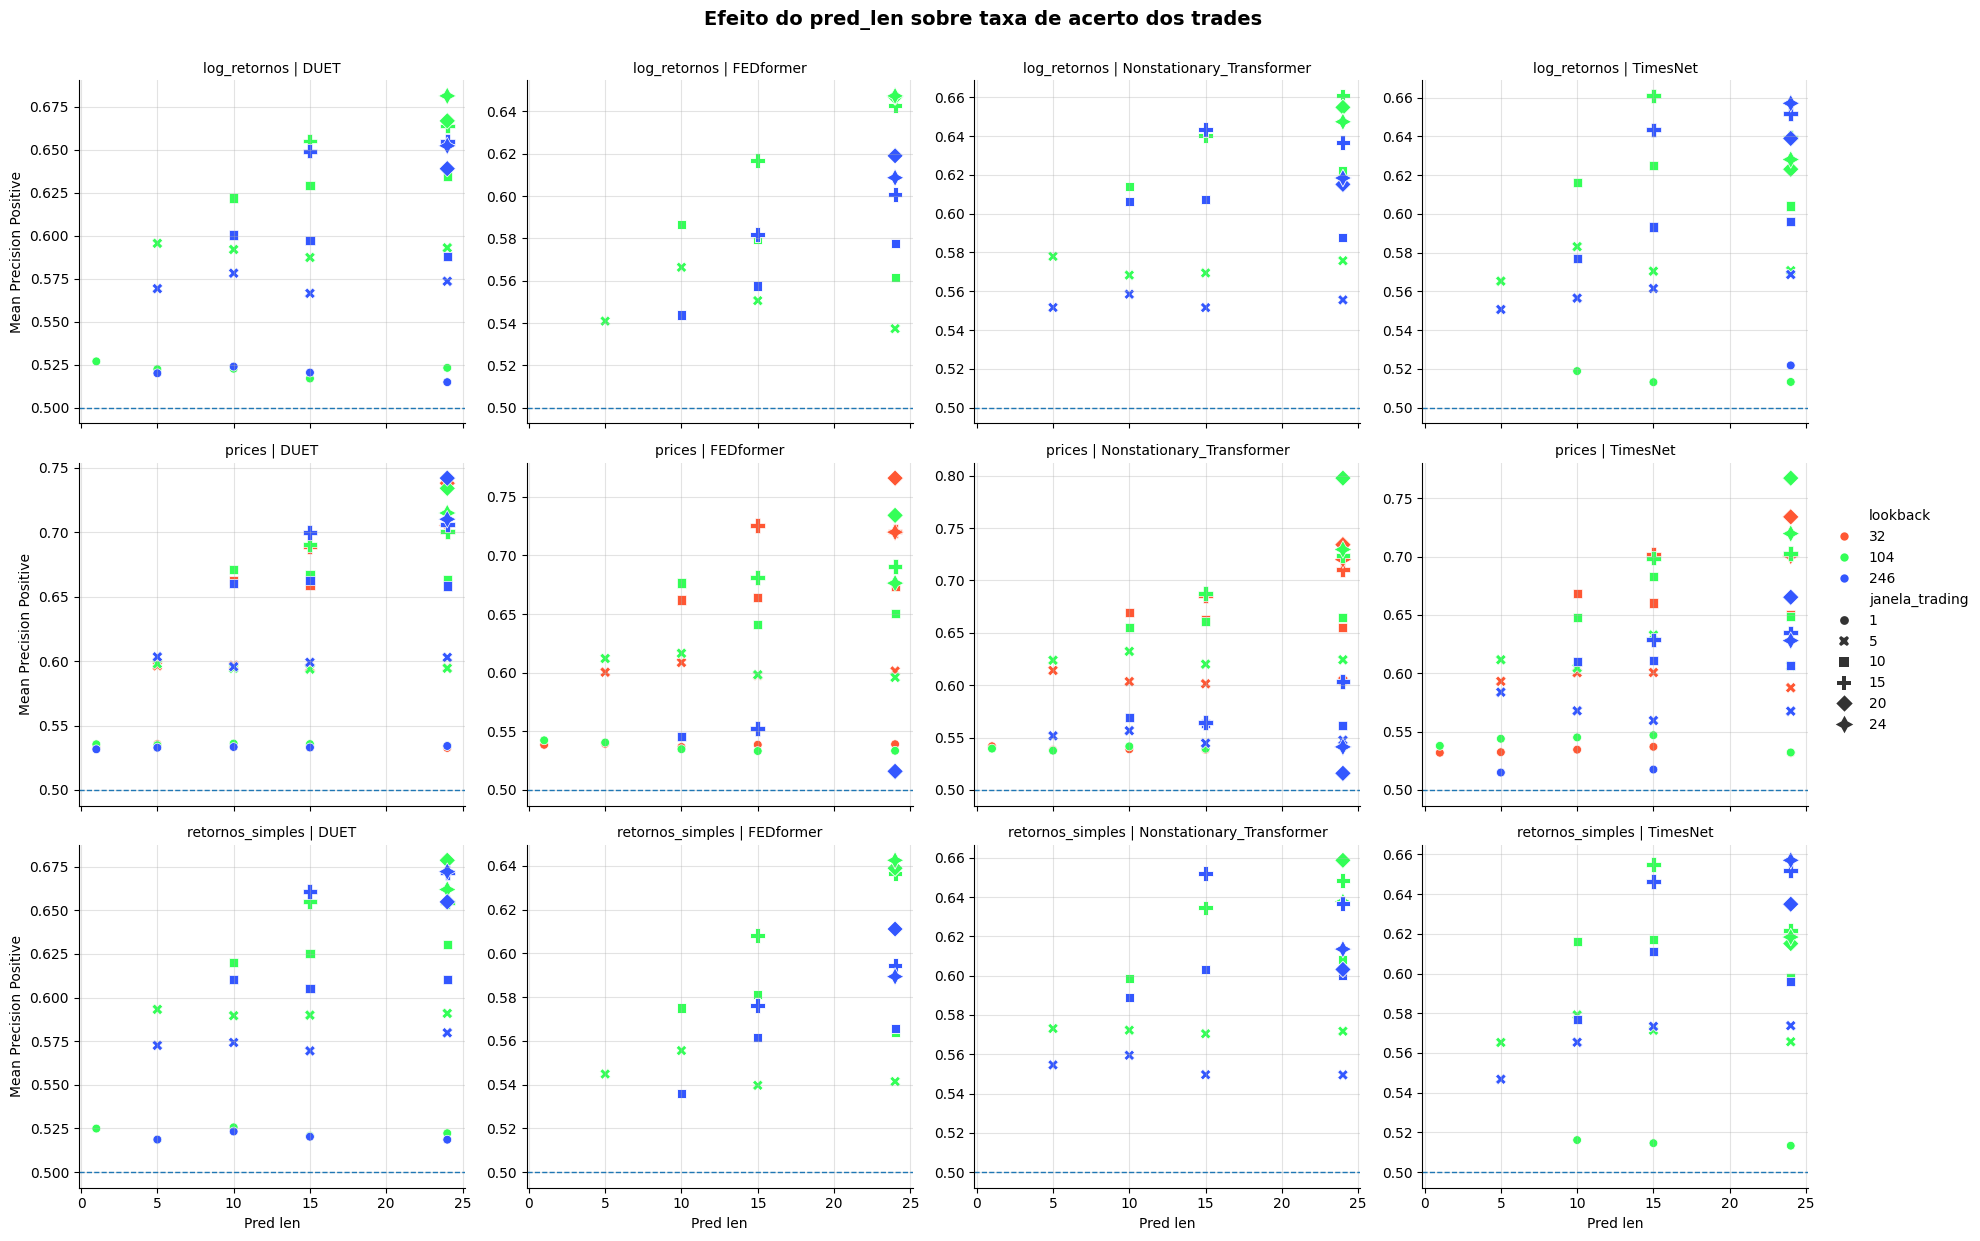

In [15]:
THRESHOLD_IC = 0.05
MIN_N_ASSETS = 5.0

df_plot = df_wide[
    (df_wide["mean_spearman_ic"] >= THRESHOLD_IC) &
    (df_wide["mean_n_assets"] >= MIN_N_ASSETS)
].copy()



g = sns.relplot(
    data=df_plot,
    x="pred_len",
    y="mean_precision_positive",
    hue="lookback",
    style="janela_trading",
    size="janela_trading",
    col="modelo",
    row="tipo_dado",
    kind="scatter",
    height=4,
    aspect=1.15,
    sizes=(40, 160),
    facet_kws={"sharey": False},
    palette={32: "#FF5733", 104: "#33FF57", 246: "#3357FF"}  # <--- CORES PERSONALIZADAS AQUI

)

g.set_axis_labels("Pred len", "Mean Precision Positive")
g.set_titles("{row_name} | {col_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.35)

g.fig.suptitle(
    "Efeito do pred_len sobre taxa de acerto dos trades",
    y=1.03,
    fontsize=14,
    fontweight="bold",
)

plt.show()
g.set_axis_labels("Pred len", "Mean Precision Positive")
g.set_titles("{row_name} | {col_name}")

for ax in g.axes.flat:
    ax.axhline(0.5, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.35)

g.fig.suptitle(
    "Efeito do pred_len sobre taxa de acerto dos trades",
    y=1.03,
    fontsize=14,
    fontweight="bold",
)

plt.show()

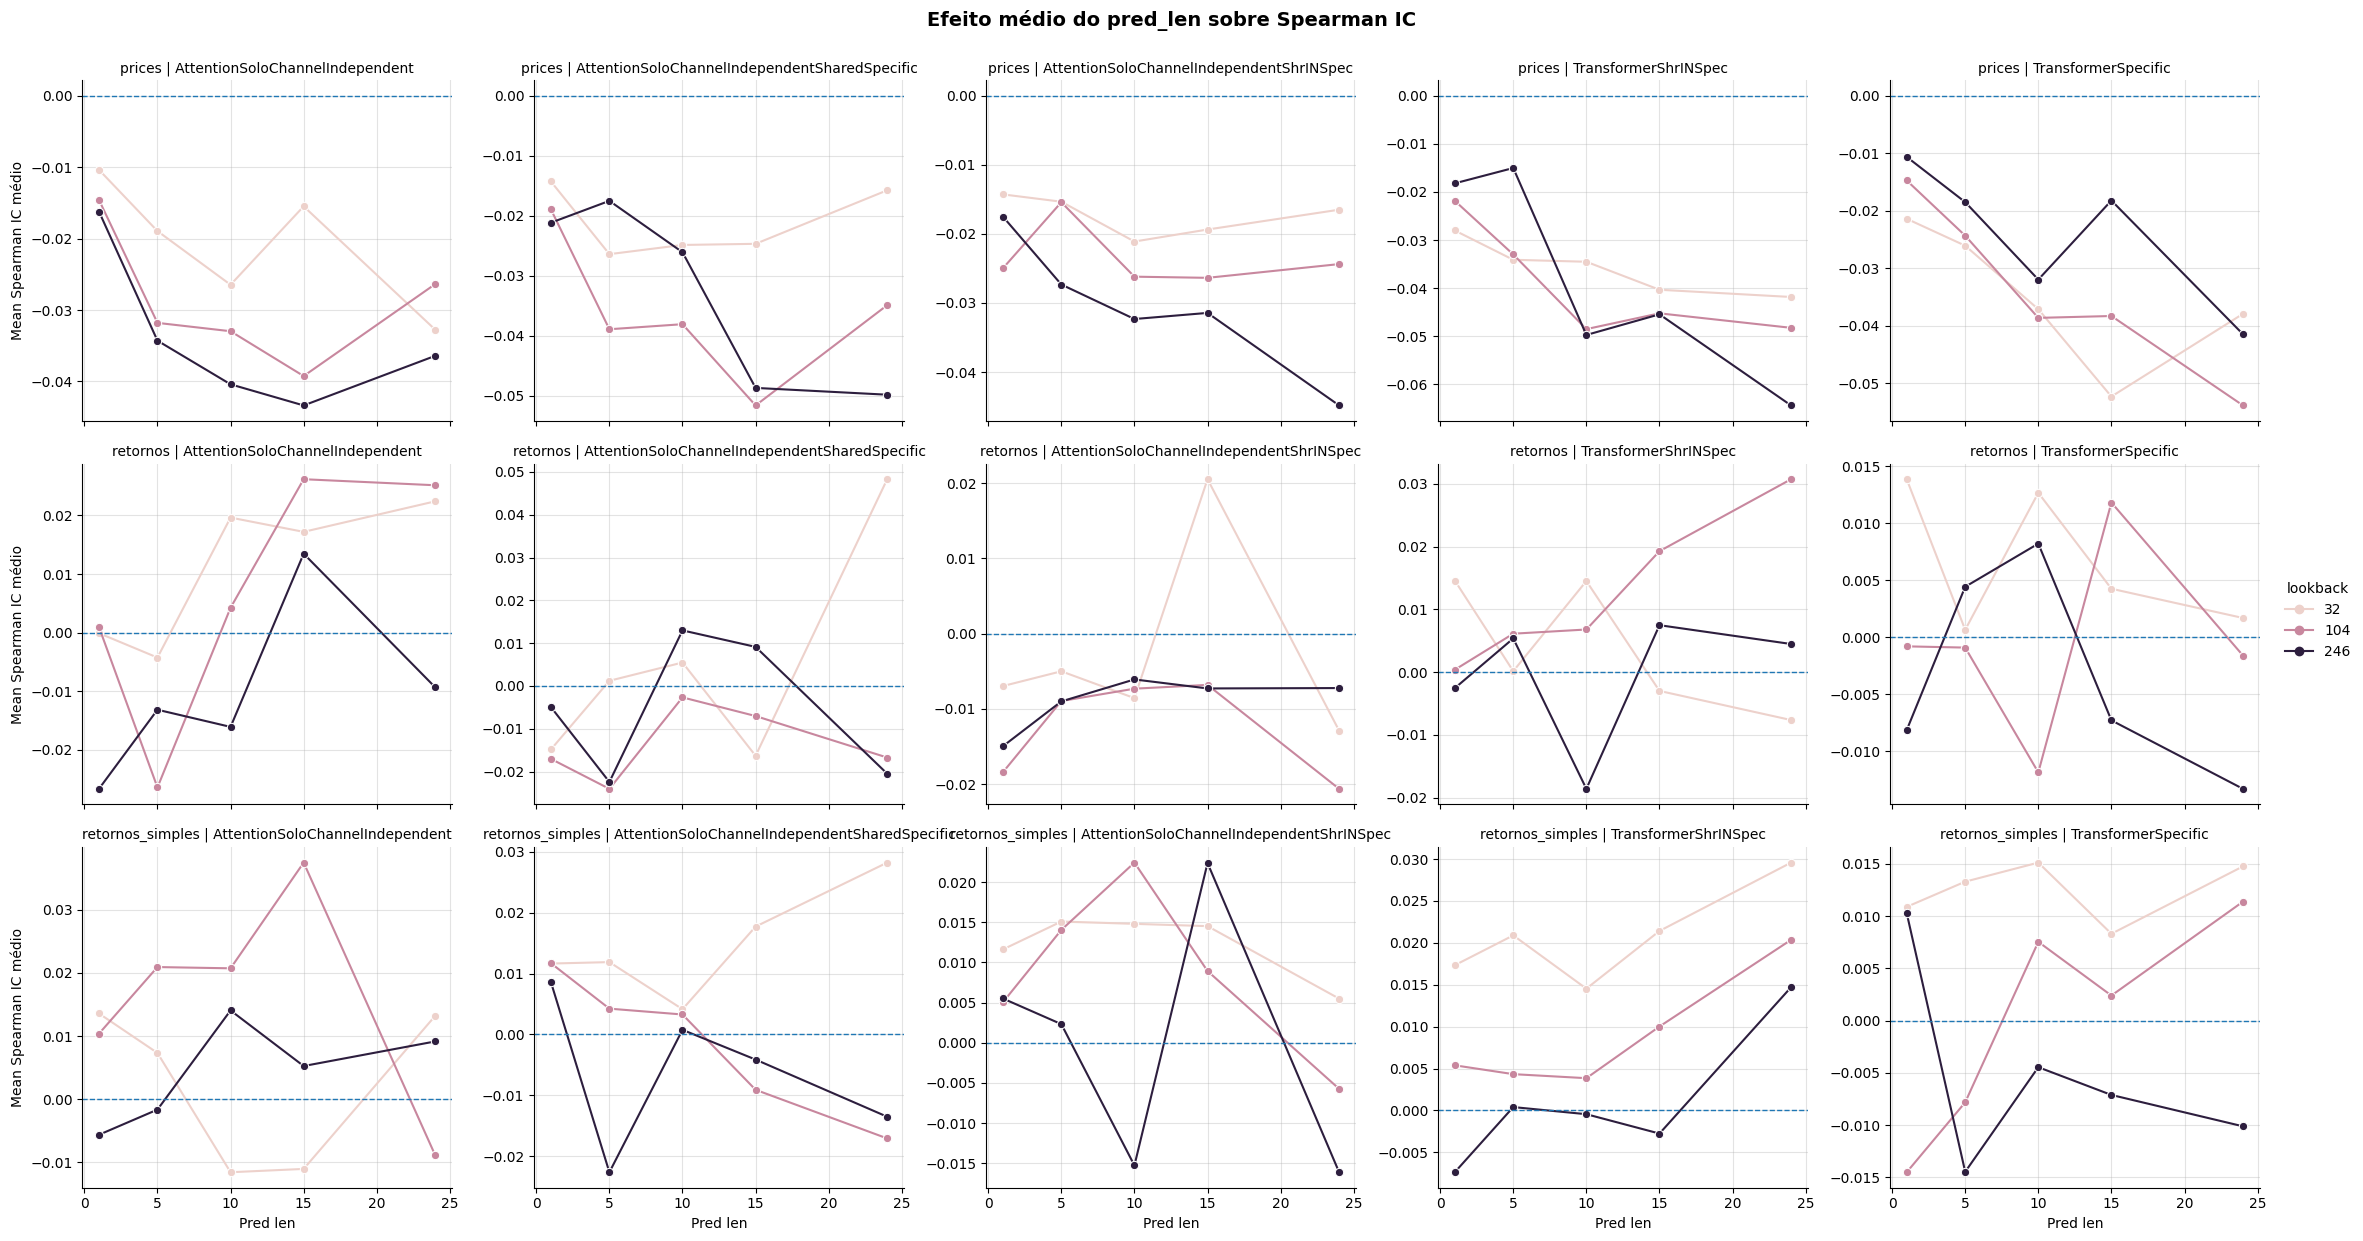

In [10]:
resumo_predlen = (
    df_wide
    .groupby(["tipo_dado", "modelo", "lookback", "pred_len"])
    .agg(
        spearman_medio=("mean_spearman_ic", "mean"),
        spearman_max=("mean_spearman_ic", "max"),
        precision_media=("mean_precision_positive", "mean"),
        precision_max=("mean_precision_positive", "max"),
        n_configs=("mean_spearman_ic", "size"),
    )
    .reset_index()
)
g = sns.relplot(
    data=resumo_predlen,
    x="pred_len",
    y="spearman_medio",
    hue="lookback",
    col="modelo",
    row="tipo_dado",
    kind="line",
    marker="o",
    height=4,
    aspect=1.15,
    facet_kws={"sharey": False},
)

g.set_axis_labels("Pred len", "Mean Spearman IC médio")
g.set_titles("{row_name} | {col_name}")

for ax in g.axes.flat:
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.grid(True, alpha=0.35)

g.fig.suptitle(
    "Efeito médio do pred_len sobre Spearman IC",
    y=1.03,
    fontsize=14,
    fontweight="bold",
)

plt.show()